In [ ]:
# 1. ติดตั้ง YOLO
!pip install ultralytics -q

# 2. เชื่อมต่อ Google Drive
# Clear the mount point if it contains files from a previous attempt
!rm -rf /content/drive/*
from google.colab import drive
drive.mount('/content/drive')

print("ติดตั้งและเชื่อมต่อ Google Drive สำเร็จ")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.4 MB/s eta 0:00:00
Mounted at /content/drive
ติดตั้งและเชื่อมต่อ Google Drive สำเร็จ


In [ ]:
import os

yaml_path = '/content/drive/MyDrive/data check lot/data.yaml'

yaml_content = """
train: /content/drive/MyDrive/data check lot/train/images
val: /content/drive/MyDrive/data check lot/val/images

nc: 9
names: ['back_label_lot', 'back_label_name', 'back_label_size','capsule_box', 'container_label_box', 'container_label_sachet', 'grade_bag_lot', 'grade_bag_product', 'retail_sachet_lot']
"""


os.makedirs(os.path.dirname(yaml_path), exist_ok=True)


with open(yaml_path, 'w') as f:
    f.write(yaml_content.strip())

print(f"สร้างไฟล์ data.yaml สำเร็จแล้วที่: {yaml_path}")

สร้างไฟล์ data.yaml สำเร็จแล้วที่: /content/drive/MyDrive/data check lot/data.yaml


In [ ]:
#v8-12
from ultralytics import YOLO

model = YOLO('yolo11s.pt')

print("เริ่มเทรนโมเดล")
results = model.train(
    data='/content/drive/MyDrive/data check lot/data.yaml',
    epochs=250,
    imgsz=1024,
    batch=16,
    name='ai_check lot v3',
    patience=30,

    # การปรับแต่งรูปทรง
    degrees=180.0,  # หมุนได้ครบ 360° (-180 ถึง +180)
    translate=0.1,
    scale=0.2,
    mosaic=0.5,
    shear=2.0,
)
print("🎉 เทรนเสร็จสมบูรณ์!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
เริ่มเทรนโมเดล
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/data check lot/data.yaml, degrees=180.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=250, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, 

ทดสอบ model
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,416,283 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 194.8±75.6 MB/s, size: 638.2 KB)
val: Scanning /content/drive/MyDrive/data check lot/val/labels.cache... 88 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 88/88 30.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.7s/it 10.1s
                   all         88        158      0.992      0.983      0.995       0.79
        back_label_lot         20         20      0.967          1      0.995      0.798
       back_label_name         20         20      0.993          1      0.995      0.874
       back_label_size         20         20      0.996          1      0.995      0.788
           capsule_box          8          8      0.996          1      0.995      0.823
   container_label_

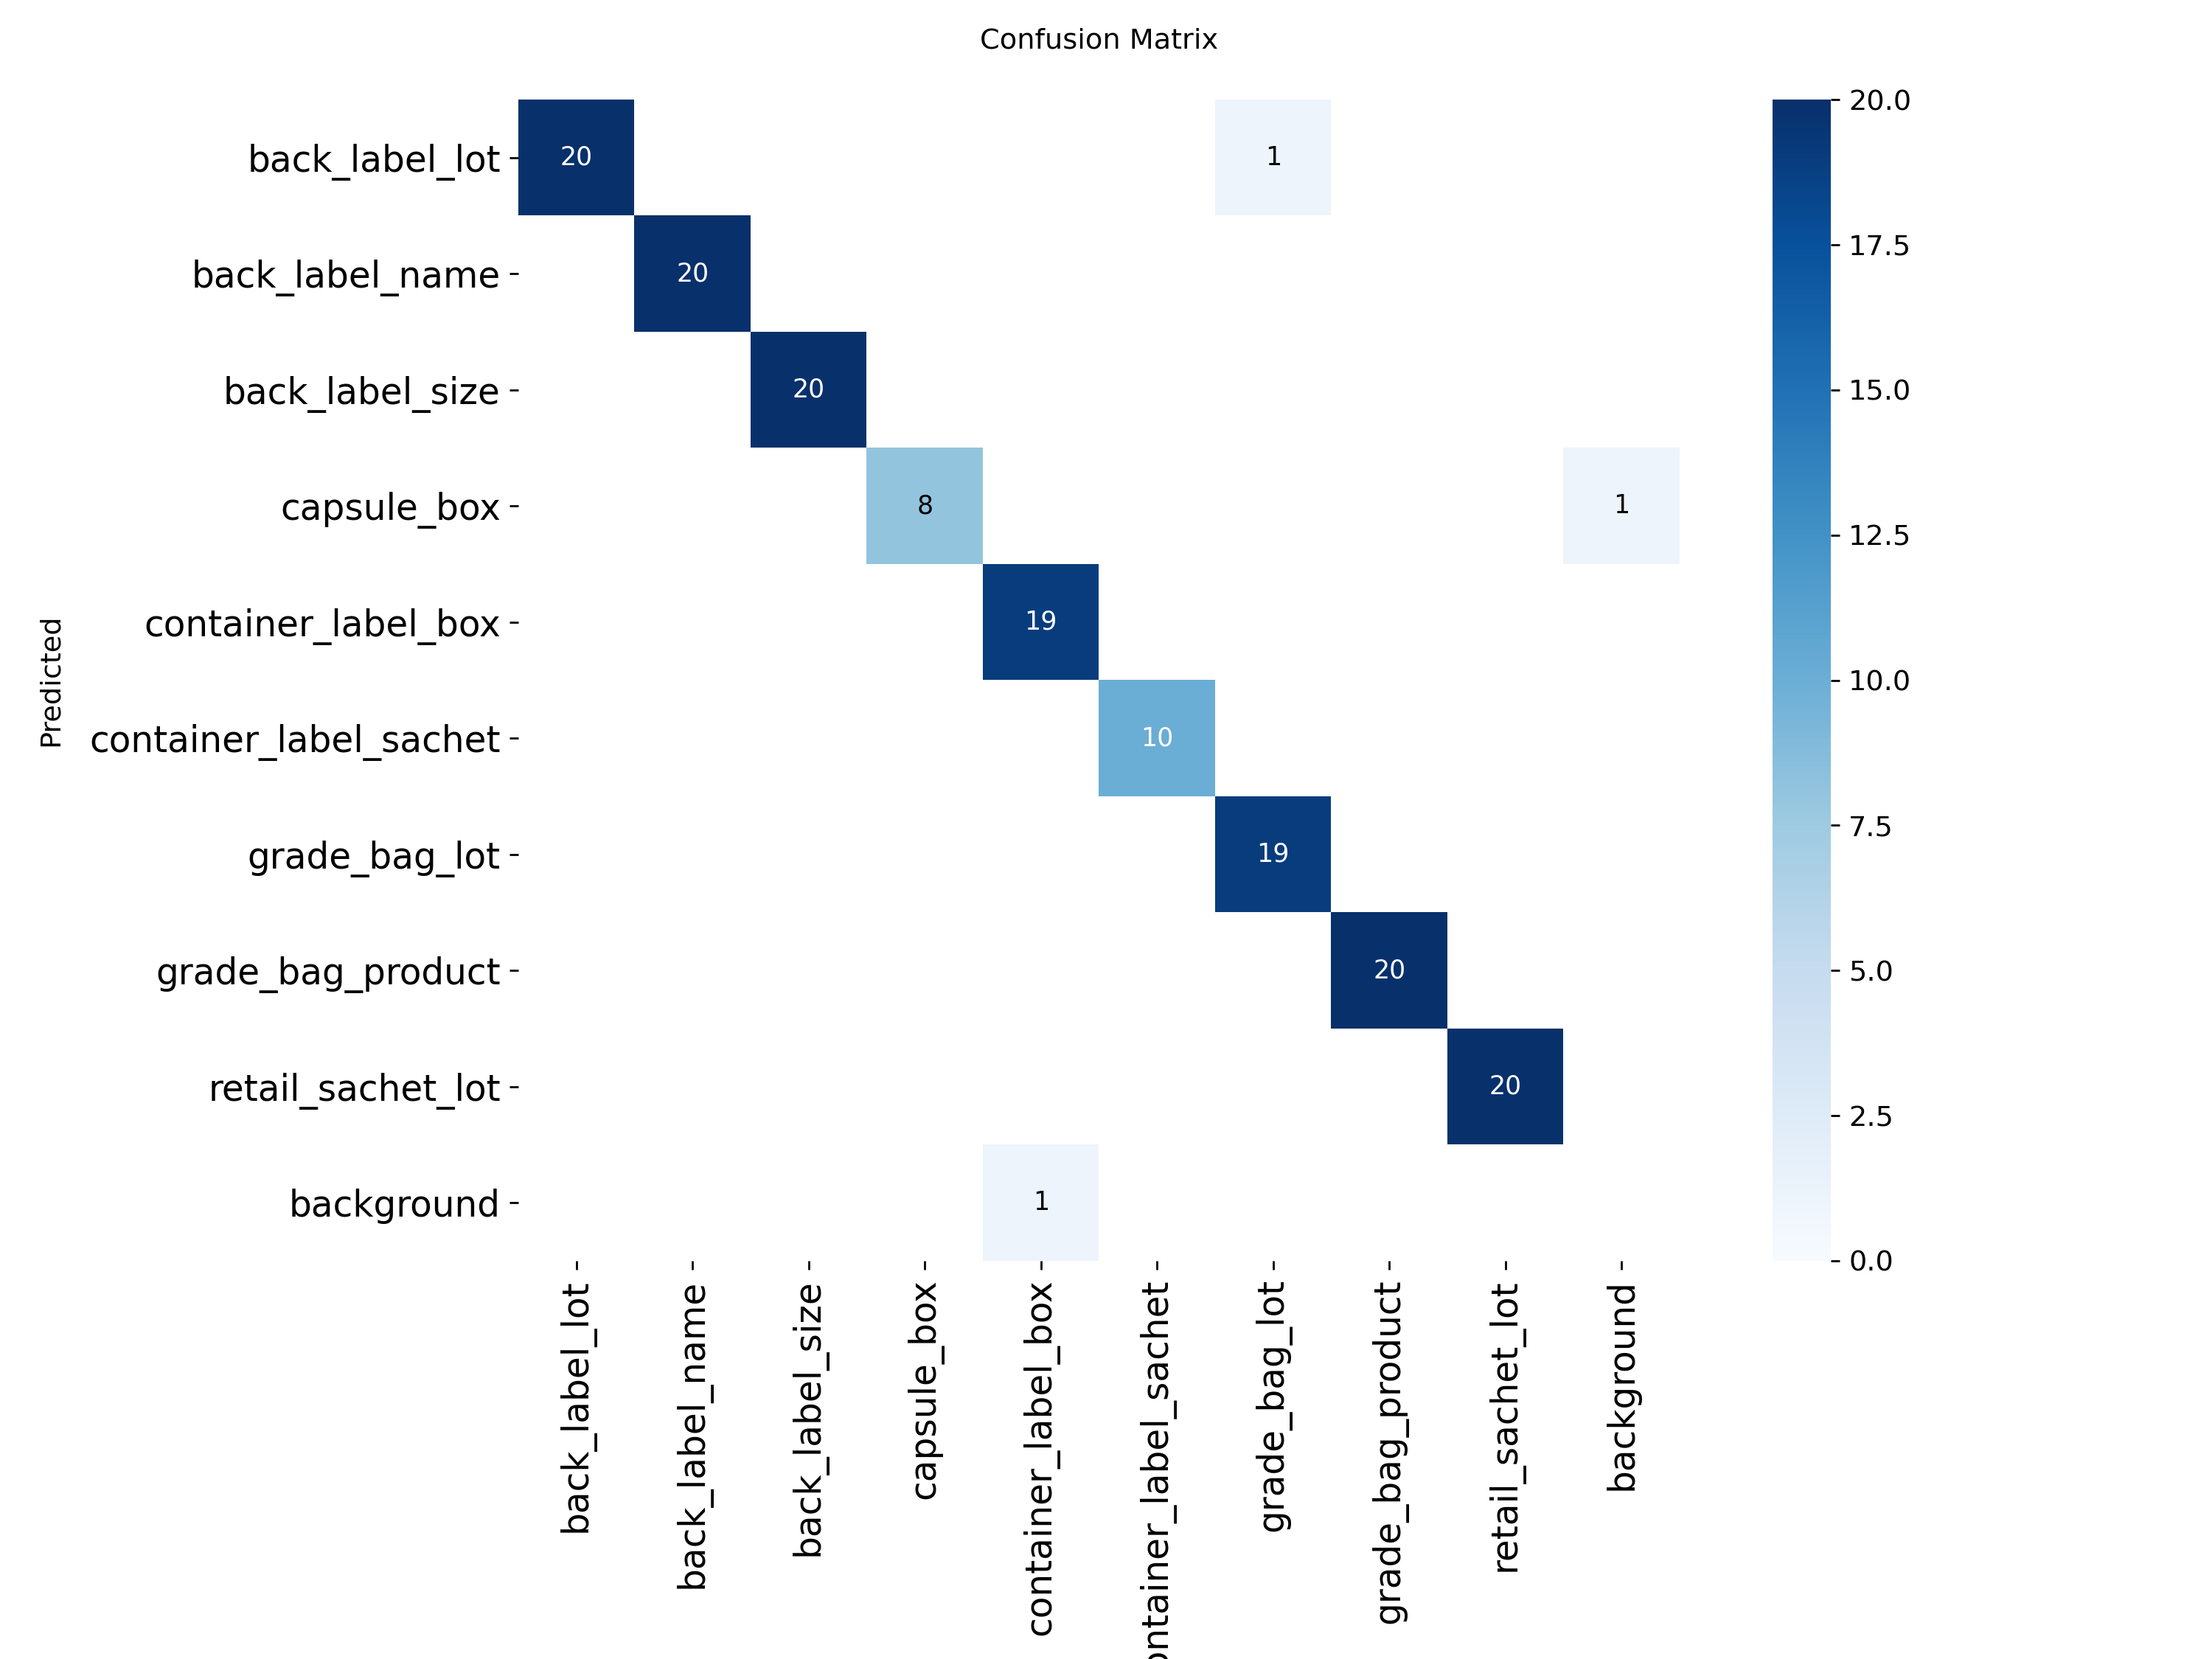

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import os
import numpy as np

# 1. โหลดโมเดล
best_model = YOLO('/content/runs/detect/ai_check lot v3/weights/best.pt')
print("ทดสอบ model")

# 2. วัดผล
metrics = best_model.val()

# 3. mAP รวม
map50 = metrics.box.map50
print("\n" + "="*50)
print(f"🎯 ความแม่นยำรวม (mAP50): {map50 * 100:.2f}%")
print("="*50)

# 4. ดึงค่า Precision / Recall / Accuracy ต่อ class
print("\n📊 ผลลัพธ์รายคลาส:")
print("-"*70)
print(f"{'Class':<25} {'Precision':>10} {'Recall':>10} {'mAP50':>10} {'F1-Score':>10}")
print("-"*70)

class_names = best_model.names  # dict {0: 'classA', 1: 'classB', ...}

# metrics.box.p = precision ต่อ class, metrics.box.r = recall ต่อ class
precision_per_class = metrics.box.p      # array shape: (num_classes,)
recall_per_class    = metrics.box.r      # array shape: (num_classes,)
ap50_per_class      = metrics.box.ap50   # array shape: (num_classes,)

for i, name in class_names.items():
    p  = precision_per_class[i]
    r  = recall_per_class[i]
    ap = ap50_per_class[i]
    f1 = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0
    print(f"{name:<25} {p*100:>9.2f}% {r*100:>9.2f}% {ap*100:>9.2f}% {f1*100:>9.2f}%")

print("-"*70)

# 5. ค่าเฉลี่ยรวมทุก class (Macro Average)
mean_p  = np.mean(precision_per_class)
mean_r  = np.mean(recall_per_class)
mean_ap = np.mean(ap50_per_class)
mean_f1 = (2 * mean_p * mean_r / (mean_p + mean_r)) if (mean_p + mean_r) > 0 else 0.0
print(f"{'📌 Macro Average':<25} {mean_p*100:>9.2f}% {mean_r*100:>9.2f}% {mean_ap*100:>9.2f}% {mean_f1*100:>9.2f}%")
print("="*70)

# 6. Accuracy จาก Confusion Matrix (TP ทั้งหมด / ทั้งหมด)
# YOLO เก็บ confusion matrix ใน metrics.confusion_matrix.matrix
cm = metrics.confusion_matrix.matrix  # shape: (num_classes+1, num_classes+1)
tp_total  = np.trace(cm)              # TP ทุก class รวมกัน
all_total = cm.sum()
overall_accuracy = tp_total / all_total if all_total > 0 else 0.0
print(f"\n🎯 Overall Accuracy (จาก Confusion Matrix): {overall_accuracy*100:.2f}%")
print("   (TP ทั้งหมด / Prediction ทั้งหมด รวม Background)")

# 7. แสดง Confusion Matrix
save_dir = metrics.save_dir
cm_path  = os.path.join(save_dir, 'confusion_matrix.png')
if os.path.exists(cm_path):
    print("\n📊 Confusion Matrix:")
    display(Image(filename=cm_path, width=800))

In [ ]:
import shutil, json, os
from pathlib import Path

DRIVE_DET = '/content/drive/MyDrive/data check lot'
source_model = '/content/runs/detect/ai_check lot v3/weights/best.pt'
destination_model = f'{DRIVE_DET}/full_detector.pt'
shutil.copy(source_model, destination_model)
print('saved detector to', destination_model)

train_imgs = len(list(Path(f'{DRIVE_DET}/train/images').glob('*')))
val_imgs   = len(list(Path(f'{DRIVE_DET}/val/images').glob('*')))
eval_data = {
    'detector_mAP_50': float(metrics.box.map50),
    'precision':       float(metrics.box.mp),
    'recall':          float(metrics.box.mr),
    'epochs':          int(getattr(results, 'epoch', 0) or 0) or 300,
    'imgsz':           640,
    'train_count':     train_imgs,
    'val_count':       val_imgs,
}
# eval.json written LAST — its presence is the "training done" signal
with open(f'{DRIVE_DET}/eval.json', 'w', encoding='utf-8') as f:
    json.dump(eval_data, f, ensure_ascii=False, indent=2)
print('wrote eval.json:', eval_data)

✅ คัดลอกโมเดลไปเก็บรักษาไว้ใน Google Drive สำเร็จ!
📁 เข้าไปดูไฟล์ได้ที่: /content/drive/MyDrive/data check lot/ai_check lot v3.pt
